In [1]:
from tensorflow.keras import Sequential

from tensorflow.keras.layers import Input, Dense, Dropout, Flatten

from tensorflow.keras.layers import Conv2D, MaxPooling2D

I0000 00:00:1780970298.196213    9978 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780970298.196842    9978 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780970298.252587    9978 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780970300.089537    9978 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## CNN in MNIST Data

In [2]:
from tensorflow.keras.datasets import mnist 
# from tensorflow.keras.datasets import cifar10 

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

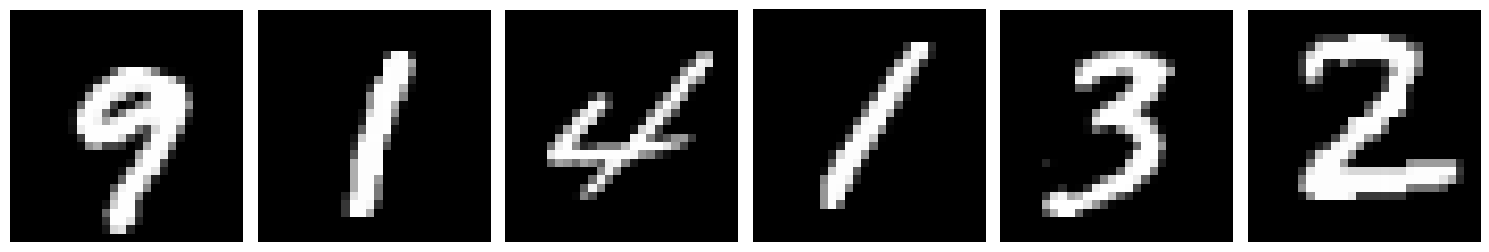

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Select 6 images (you can choose specific indices if needed)
indices = np.random.choice(len(X_train), 6, replace=False)
selected_images = [X_train[i] for i in indices]

# Create subplots
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

# Plot each image
for ax, img in zip(axes, selected_images):
    ax.imshow(img, cmap='gray')  # Display image in grayscale
    ax.axis('off')  # Turn off axes for a cleaner look

# Display the plot
plt.tight_layout()
plt.show()

In [5]:
# Data Preprocessing

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

# min-max scaling
X_train = X_train / 255
X_test = X_test / 255

In [6]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False)

enc_y_train = onehot_encoder.fit_transform(y_train.reshape(-1,1))

## Model Defination

In [7]:
input_shape = X_train.shape[1:]
input_shape

(28, 28, 1)

In [8]:
model = Sequential()

model.add(Input(shape=input_shape))

# Convo Layer 1
model.add(Conv2D(filters = 6, kernel_size=(5,5), strides=(1,1), padding="valid", activation="relu" ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Convo Layer 2
model.add(Conv2D(filters = 16, kernel_size=(5,5), strides=(1,1), padding="valid", activation="relu" ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))


model.add(Flatten())

# Fully Conneced Layer
model.add(Dense(100, activation="relu"))

model.add(Dropout(0.25))

model.add(Dense(50, activation="relu"))

model.add(Dense(10, activation="softmax"))


model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)


E0000 00:00:1780970302.050188    9978 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,832 (132.16 KB)

 Trainable params: 33,832 (132.16 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, 
    enc_y_train, 
    epochs=25, 
    batch_size=32,
    shuffle=True,
    validation_split = 0.2
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9135 - loss: 0.2735 - val_accuracy: 0.9726 - val_loss: 0.0875
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9689 - loss: 0.1022 - val_accuracy: 0.9799 - val_loss: 0.0658
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9768 - loss: 0.0780 - val_accuracy: 0.9827 - val_loss: 0.0558
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9809 - loss: 0.0626 - val_accuracy: 0.9846 - val_loss: 0.0524
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9830 - loss: 0.0545 - val_accuracy: 0.9867 - val_loss: 0.0487
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9852 - loss: 0.0460 - val_accuracy: 0.9856 - val_loss: 0.0478
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 0.9868 - val_loss: 0.0460
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9884 - lo

<Axes: >

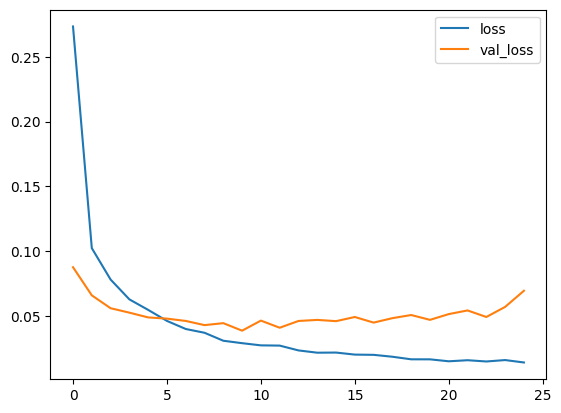

In [11]:
import pandas as pd

df = pd.DataFrame(history.history)
df[['loss','val_loss']].plot.line()

In [12]:
from sklearn.metrics import confusion_matrix

pred = np.argmax(model.predict(X_test), axis=1)
confusion_matrix(y_test, pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[ 970,    0,    1,    0,    4,    0,    1,    1,    0,    3],
       [   0, 1130,    0,    0,    1,    1,    2,    0,    1,    0],
       [   1,    1, 1023,    0,    4,    0,    0,    3,    0,    0],
       [   0,    0,    2,  993,    0,    4,    0,    2,    5,    4],
       [   0,    0,    0,    0,  980,    0,    0,    2,    0,    0],
       [   1,    0,    0,    4,    0,  885,    2,    0,    0,    0],
       [   3,    1,    0,    0,    3,    2,  949,    0,    0,    0],
       [   0,    3,    4,    0,    1,    0,    0, 1014,    2,    4],
       [   3,    0,    3,    1,    2,    1,    1,    1,  959,    3],
       [   0,    0,    0,    1,   20,    4,    0,    5,    5,  974]])